## Исследование данных о российском кинопрокате



Заказчик этого исследования — Министерство культуры Российской Федерации. 

Требуется изучить рынок российского кинопроката и выявить текущие тренды. Уделите внимание фильмам, которые получили государственную поддержку. Попробуйте ответить на вопрос, насколько такие фильмы интересны зрителю. 

Работать требуется с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 

In [364]:
import pandas as pd
import numpy as np
import os.path
from pandas.api.types import is_numeric_dtype
from pandas.api.types import is_string_dtype
import matplotlib.pyplot as plt
import seaborn as sns

### Шаг 1. Откроем файлы с данными и объединим их в один датафрейм. 

In [365]:
def describe_field(data, field_name):
    display (f"amount of NaN is {data[field_name].isna().sum()}, {(data[field_name].isna().sum() / len(data) * 100).astype('int')}%")
    if is_numeric_dtype(data[field_name]):
        print('numeric, describe():')
        display(data[field_name].describe())
    else:
        print('not numeric, value_counts():')
        display(data[field_name].value_counts())

def plot_two_factors(data, factor1, factor2):
      l = len(data[factor1].unique())
      if l < 15:
            (data.groupby(by=factor1)['box_office']
            .sum()
            .plot( y=factor2, kind='bar', figsize=(3,3), title='зависимость между факторами',
                  xlabel=factor1, ylabel=factor2)
            )
            plt.show()
      else:
            display(f'слишком много значений для представлении на графике: {l}')

In [366]:
csv_path = 'mkrf_shows.csv'
if not os.path.exists(csv_path):
    csv_path = '/datasets/' + csv_path

data_shows = pd.read_csv(csv_path)
display(data_shows.info())
display(data_shows.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


None

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [367]:
csv_path = 'mkrf_movies.csv'
if not os.path.exists(csv_path):
    csv_path = '/datasets/' + csv_path

data_movies = pd.read_csv(csv_path)
display(data_movies.info())
display(data_movies.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

None

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


Объединим таблицы.

In [368]:
data_shows['puNumber'] = data_shows['puNumber'].astype('string')
data_movies['puNumber'] = data_movies['puNumber'].astype('string')
data = data_movies.merge(data_shows, on='puNumber', how='left')
data = data.rename(columns={'puNumber':'pu_number'})


проверим, что сборы добавились:

In [369]:
display(data[~data['box_office'].isna()].head(3))
display(data.info())

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
18,Неподдающиеся,111003616,2016-02-12T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Ю.Чулюкин,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.0,"мелодрама,комедия",360.0
19,Неподсуден,111003716,2016-02-12T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Краснопольский, В.Усков",NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,420.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   pu_number              7486 non-null   string 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

None

Таблица содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений. 
<pre>
- title — название фильма;
- pu_number — номер прокатного удостоверения;
- show_start_date — дата премьеры фильма;
- type — тип фильма;
- film_studio — студия-производитель;
- production_country — страна-производитель;
- director — режиссёр;
- producer — продюсер;
- age_restriction — возрастная категория;
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;
- budget — общий бюджет фильма; уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку.
- ratings — рейтинг фильма на КиноПоиске;
- genres — жанр фильма.
- box_office — сборы в рублях.
</pre>

### Шаг 2. Предобработка данных

#### Шаг 2.1. Проверим типы данных

In [370]:
data['show_start_date'] = pd.to_datetime(data['show_start_date'])

In [371]:
describe_field(data, 'ratings')

'amount of NaN is 967, 12%'

not numeric, value_counts():


ratings
6.6    312
6.7    308
6.8    261
7.2    252
6.2    243
      ... 
19%      1
90%      1
62%      1
64%      1
9.1      1
Name: count, Length: 94, dtype: int64

#### Шаг 2.2. Изучим пропуски в датафрейме

получим список полей с пропусками и рассмотрим их затем по очереди

In [372]:
nans = data.isna().sum()
nans = nans[nans > 0]
nans

film_studio                18
production_country          2
director                    9
producer                  568
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   967
genres                    976
box_office               4328
dtype: int64

film_studio

In [373]:
describe_field(data, 'film_studio')

'amount of NaN is 18, 0%'

not numeric, value_counts():


film_studio
Киностудия "Мосфильм"                                                                                                      341
ООО "Мульт в кино"                                                                                                          57
Анимаккорд Лтд                                                                                                              23
ООО "Мульт в кино"                                                                                                          18
ФГУП "ТПО "Киностудия "Союзмультфильм"                                                                                      16
                                                                                                                          ... 
МортуСкрин, Игл Рок Интертейнмент                                                                                            1
Эден Рок Медиа, Филм Нэйшн Интертейнмент, Флинн Пикчерз Компани, Нью Лайн Синема, Силвер Рил, Супер

In [374]:
data[data['film_studio'].isna()].head()

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1293,Stars in Shorts,121011114,2014-06-03 12:00:00+00:00,Художественный,NaN,"США, Великобритания","Роберт Фестингер, Руперт Френд, Джей Камен, Ни...","Татьяна Келли, Роберта Мунро, Руперт Френд, До...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.3,комедия,NaN
4441,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,NaN,NaN,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,4.0,"мультфильм,комедия",NaN
6105,Значит любит,111013818,2018-08-10 12:00:00+00:00,Художественный,NaN,Россия,А.Краевский,Е.Щербакова,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6181,Несейка. Младшая дочь,112007018,2018-09-01 12:00:00+00:00,Документальный,NaN,Россия,В.Марин,"Д.Якунин, Ф.Абрютин, О.Филонова",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6379,Ян Антонышев,112011818,2018-11-15 12:00:00+00:00,Документальный,NaN,Россия,Е.Окопная,Е.Герасимов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Пока не понятно, насколько важно отсутствие этой информации для задачи исследования. Заменим на 'unknown'.

In [375]:
unknown = 'unknown'
data['film_studio'] = data['film_studio'].fillna(unknown)

production_country

In [376]:
data[data['production_country'].isna()]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3186,"Детский юмористический киножурнал ""Ералаш. Ну ...",111001216,2016-02-09 12:00:00+00:00,Художественный,"ООО ""Продюсерский центр ЕРАЛАШ""",NaN,"Р.Светлов, И.Магитон, А.Арутюнян, Л.Мирский, А...","ООО ""Продюсерский центр ЕРАЛАШ""",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.2,"детский,комедия",194527.0
4441,Мульт личности. Выпуск 5,214000410,2010-01-25 12:00:00+00:00,Художественный,unknown,NaN,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,4.0,"мультфильм,комедия",NaN


заменим на Росссию

In [377]:
data['production_country'] = data['production_country'].fillna('Россия')

director

In [378]:
data[data['director'].isna()].head()

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
764,"Три звезды. Концерт в Waldbuhne Theater, Берли...",126003512,2012-12-04 12:00:00+00:00,Прочие,Райзинг Алтернатив,Великобритания,NaN,Вальдбюне Театр,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,44350.0
1735,Помпеи. Британский музей,126003413,2013-09-11 12:00:00+00:00,Прочие,"МортуСкрин, Британский музей",Великобритания,NaN,Британский музей,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3840,Зур концерт (Большой концерт).,217027010,2010-06-24 12:00:00+00:00,Художественный,"ООО ""Барс Рекордс""",Россия,NaN,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4052,"Ганс Сэйфуллин ""Авылым чишмэлэре. Ганс Сэйфулл...",217017310,2010-04-22 12:00:00+00:00,Художественный,"ООО ""Барс-Рекордс""",Россия,NaN,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4298,Изге Вэли (Святой Валентин),217020610,2010-05-20 12:00:00+00:00,Художественный,"ООО ""Барс Рекордс""",Россия,NaN,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Пока не понятно, насколько важно отсутствие этой информации для задачи исследования. Откуда брать директора - идей пока нет.  Заменим на 'unknown'.

In [379]:
data['director'] = data['director'].fillna(unknown)

producer

In [380]:
data[data['producer'].isna()].head()

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN
11,Ответный ход,111019014,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,М.Туманишвили,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"боевик,драма,приключения",NaN


Пока не понятно, насколько важно отсутствие этой информации для задачи исследования. Откуда брать продюсора - идей пока нет.  Заменим на 'unknown'.

In [381]:
data['producer'] = data['producer'].fillna(unknown)

Следующие поля имеют одинаковое количество NaN:

- refundable_support       7154
- nonrefundable_support    7154
- budget                   7154
- financing_source         7154

Интересно, одни ли и те же это записи? Проверим:

In [382]:
len(data.query('refundable_support.isnull() and nonrefundable_support.isnull() and budget.isnull() and financing_source.isnull()'))

7154

Да, пересечение всех этих множество пустых полей - имеет всё тот же объём = 7154. Значит все эти записи пусты одновременно.

Все остальные фильмы (без господдержки) - стоит оставить с NaN. Поскольку их бюджеты (поле budget) нам не известны (и не корктно было бы их обнулять или вычислять для них среднее). А остальные 3 поля к ним вовсе неприменимы.

Посмотрим, есть ли математическая связь между полями про бюджет:

In [383]:
data[['refundable_support', 'nonrefundable_support', 'budget', 'financing_source']].query('budget==0')

,refundable_support,nonrefundable_support,budget,financing_source
2053,0.0,23000000.0,0.0,"Министерство культуры, Фонд кино"
2058,0.0,75000000.0,0.0,Фонд кино
2472,10000000.0,70000000.0,0.0,Фонд кино
2532,20000000.0,0.0,0.0,Фонд кино
2615,60000000.0,100000000.0,0.0,Фонд кино
2684,0.0,59000000.0,0.0,Фонд кино
2788,0.0,35000000.0,0.0,Фонд кино
2874,0.0,6000000.0,0.0,Министерство культуры
3047,19000000.0,51000000.0,0.0,Фонд кино
3565,0.0,250000000.0,0.0,Фонд кино


Никакой связи пока выявить между ними не удалось.

Поле ratings

In [384]:
data['ratings'].value_counts()

ratings
6.6    312
6.7    308
6.8    261
7.2    252
6.2    243
      ... 
19%      1
90%      1
62%      1
64%      1
9.1      1
Name: count, Length: 94, dtype: int64

Избавимся от знаков %, взяв рейтинг Кинопоиска 10.0 за 100%. 

In [385]:
def remove_percent(sarg):
    s = str(sarg)
    if '%' in s:
        return  float(s.replace('%',''))/10
    return float(s)

data['ratings'] = data['ratings'].apply(remove_percent)

In [386]:
describe_field(data, 'ratings')

'amount of NaN is 967, 12%'

numeric, describe():


count    6519.000000
mean        6.488173
std         1.114638
min         1.000000
25%         5.900000
50%         6.600000
75%         7.200000
max         9.900000
Name: ratings, dtype: float64

Пропуски рейтингов (12%) заполнять ничем не будем, т. к. это основной параметр исследования. Было бы несправедливо присуживать медианные значения плохим фильмам, или обнулять рейтинги хороших (не набравших пока голосов) фильмов. Возможно, проще будет их позже удалить или убрать из рассмотрения, если будет мешать.

Поле genres

In [387]:
describe_field(data, 'genres')

'amount of NaN is 976, 13%'

not numeric, value_counts():


genres
драма                           476
комедия                         352
мелодрама,комедия               222
драма,мелодрама,комедия         189
драма,мелодрама                 183
                               ... 
мюзикл,фэнтези,семейный           1
мюзикл,мелодрама,фэнтези          1
документальный,новости,драма      1
семейный,детектив,детский         1
мелодрама,история,драма           1
Name: count, Length: 742, dtype: int64

In [388]:
data['genres'] = data['genres'].fillna(unknown)

Поле box_office               

In [389]:
describe_field(data, 'box_office')

'amount of NaN is 4328, 57%'

numeric, describe():


count    3.158000e+03
mean     7.647870e+07
std      2.403531e+08
min      0.000000e+00
25%      8.623900e+04
50%      2.327988e+06
75%      2.397967e+07
max      3.073569e+09
Name: box_office, dtype: float64

Довольно много фильмов (57%) не имеет информации о сборах. Оставим как есть.

#### Шаг 2.3. Изучим дубликаты в датафрейме

Начнём с поиска явных дубликатов:

In [390]:
data.duplicated().sum()

0

Неявные дубликаты

In [391]:
#describe_field(data, 'title')
data ['title'].value_counts()

title
День святого Валентина_                               5
Кошки против собак: Месть Китти Галор                 4
Знакомство с Факерами 2.                              4
Рапунцель: Запутанная история                         4
Секс в большом городе 2                               4
                                                     ..
МУЛЬТ в кино. Выпуск № 14                             1
Стажёр                                                1
Мэхэббэт - ул йорэк эше (Любовь - это дело сердца)    1
Иван Грозный - 2 серия (восстановленная версия)       1
Машины песенки. Серия "Когда цветут кактусы"          1
Name: count, Length: 6772, dtype: int64

In [392]:
data.query('title == "День святого Валентина_"')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3902,День святого Валентина_,221083810,2010-07-15 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
3991,День святого Валентина_,221068010,2010-05-14 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4070,День святого Валентина_,121002210,2010-02-03 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4196,День святого Валентина_,221136210,2010-11-30 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
5070,День святого Валентина_,221066410,2010-06-01 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN


Дубликаты в названиях есть, но у них разные прокатные удостоверения и даты старта показа. Оставляем как есть.

In [393]:
data['pu_number'].value_counts()

pu_number
221054410    2
221154310    2
121000612    1
111007513    1
221030815    1
            ..
124010819    1
124010619    1
126007819    1
121037019    1
124010719    1
Name: count, Length: 7484, dtype: Int64

pu_number

In [394]:
data.query('pu_number == "221054410"')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5067,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.8,"комедия,криминал",NaN


Прокатное удостоверение бывает, что дублируется. Но, возможно, это нормально - возможно, одно удостоверение выдают на несколько фильмов.

In [395]:
data['type'].value_counts()

type
Художественный                4520
 Художественный               1389
Анимационный                   828
Прочие                         406
Документальный                 288
Научно-популярный               53
 Анимационный                    1
Музыкально-развлекательный       1
Name: count, dtype: int64

В " Художественный" и " Анимационный" надо удалить лидирующие пробелы, гуглим и применяем решение:

In [396]:
#data['type'] = data['type'].apply(lambda x: x.strip())
data['type'] = data['type'].str.strip()


film_studio

In [397]:
describe_field(data,'film_studio')

'amount of NaN is 0, 0%'

not numeric, value_counts():


film_studio
Киностудия "Мосфильм"                                                                                                      341
ООО "Мульт в кино"                                                                                                          57
Анимаккорд Лтд                                                                                                              23
ООО "Мульт в кино"                                                                                                          18
unknown                                                                                                                     18
                                                                                                                          ... 
МортуСкрин, Игл Рок Интертейнмент                                                                                            1
Эден Рок Медиа, Филм Нэйшн Интертейнмент, Флинн Пикчерз Компани, Нью Лайн Синема, Силвер Рил, Супер

<- данных много, дубликатов сходу не видно, оставим как есть.

director:

In [398]:
describe_field(data,'director')

'amount of NaN is 0, 0%'

not numeric, value_counts():


director
О.Семёнова                  47
Стивен Содерберг            17
Д.Червяцов                  17
Ридли Скотт                 16
Тиль Швайгер                14
                            ..
Том Коркоран                 1
Е.Сергеев                    1
Фернандо Гонзалез Молина     1
Е.Перволовичи                1
И.Трусов                     1
Name: count, Length: 4812, dtype: int64

<- данных много, дубликатов сходу не видно, оставим как есть.

producer:

In [399]:
describe_field(data,'producer')

'amount of NaN is 0, 0%'

not numeric, value_counts():


producer
unknown                                                                       568
П.Смирнов                                                                      67
Олег Кузовков, Дмитрий Ловейко, Марина Ратина                                  28
С.Сельянов                                                                     18
Д.Ловейко, О.Кузовков                                                          17
                                                                             ... 
Б.Гуц, А.Гусенцова                                                              1
Лоран Петен, Мишель Петен                                                       1
 ООО "КиноФирма"                                                                1
Э.Илоян, В.Шляппо, А.Троцюк, Д.Жалинский, Д.Дьяченко, М.Ткаченко, А.Рубцов      1
Дженнифер Додж                                                                  1
Name: count, Length: 5350, dtype: int64

<- данных много, дубликатов сходу не видно, оставим как есть.

age_restriction:

In [400]:
describe_field(data,'age_restriction')

'amount of NaN is 0, 0%'

not numeric, value_counts():


age_restriction
«16+» - для детей старше 16 лет           2851
«18+» - запрещено для детей               1605
«12+» - для детей старше 12 лет           1593
«0+» - для любой зрительской аудитории     811
«6+» - для детей старше 6 лет              626
Name: count, dtype: int64

<- всё ок, оставим как есть.

genres:

In [401]:
describe_field(data,'genres')

'amount of NaN is 0, 0%'

not numeric, value_counts():


genres
unknown                         976
драма                           476
комедия                         352
мелодрама,комедия               222
драма,мелодрама,комедия         189
                               ... 
мюзикл,фэнтези,семейный           1
мюзикл,мелодрама,фэнтези          1
документальный,новости,драма      1
семейный,детектив,детский         1
мелодрама,история,драма           1
Name: count, Length: 743, dtype: int64

<- данных много, дубликатов сходу не видно, оставим как есть.

#### Шаг 2.4. Изучим категориальные значения

Это уже сделано выше.

#### Шаг 2.5. Проверим количественные значения

In [402]:
data[['refundable_support', 'nonrefundable_support', 'budget']].describe()

,refundable_support,nonrefundable_support,budget
count,3.320000e+02,3.320000e+02,3.320000e+02
mean,1.186446e+07,4.898099e+07,1.272297e+08
std,2.491656e+07,5.998012e+07,1.885883e+08
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.500000e+07,4.200000e+07
50%,0.000000e+00,3.000000e+07,6.864992e+07
75%,1.500000e+07,4.037500e+07,1.419853e+08
max,1.800000e+08,4.000000e+08,2.305074e+09


<- не информативно, рассмотрим по отдельности:

In [403]:
d = data[['refundable_support', 'nonrefundable_support', 'budget']].query('budget==0')
display(d)
len(d)

,refundable_support,nonrefundable_support,budget
2053,0.0,23000000.0,0.0
2058,0.0,75000000.0,0.0
2472,10000000.0,70000000.0,0.0
2532,20000000.0,0.0,0.0
2615,60000000.0,100000000.0,0.0
2684,0.0,59000000.0,0.0
2788,0.0,35000000.0,0.0
2874,0.0,6000000.0,0.0
3047,19000000.0,51000000.0,0.0
3565,0.0,250000000.0,0.0


17

<- странно, что есть фильмы с нулевым бюджетом. Ведь сумма поля budget должна включать в себя значения и господдержки тоже.

In [404]:
data[['refundable_support', 'nonrefundable_support', 'budget']].query('refundable_support + nonrefundable_support > budget')
display(d)
len(d)

,refundable_support,nonrefundable_support,budget
2053,0.0,23000000.0,0.0
2058,0.0,75000000.0,0.0
2472,10000000.0,70000000.0,0.0
2532,20000000.0,0.0,0.0
2615,60000000.0,100000000.0,0.0
2684,0.0,59000000.0,0.0
2788,0.0,35000000.0,0.0
2874,0.0,6000000.0,0.0
3047,19000000.0,51000000.0,0.0
3565,0.0,250000000.0,0.0


17

Заполним нулевые budget суммой refundable_support и nonrefundable_support, как заявлено в документации.

In [405]:
def correct_budget (d):
    if d['budget'] == 0:
        return d['refundable_support'] + d['nonrefundable_support'] 
    return d['budget']

data ['budget'] =  data.apply(correct_budget, axis=1)

#### Шаг 2.6. Добавим новые столбцы





- Создадим столбец с информацией о годе проката. Выделим год из даты премьеры фильма.

In [406]:
data['show_start_date_y'] = data['show_start_date'].dt.year

- Создим два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

In [407]:
display(data[data['director'].str.len() > 50]['director'].head(3))
display(data[data['genres'].str.len() > 20]['genres'].head(3))

389    Николас Виндинг Рефн                          ...
582    Габи Амионе, Пау Балаге, Джозеко де Линарес, Э...
607    С.Андреасян, К.Оганисян, А.Кещян, Т.Корнев, Э....
Name: director, dtype: object

0       боевик,драма,мелодрама
2    фантастика,боевик,триллер
3    фантастика,боевик,триллер
Name: genres, dtype: object

<- теперь видно, что элементы разделены запятыми, удалим заятую и всё, что после, чтобы выделить главных в списке

In [408]:
#data['director_main'] = data['director'].str.replace(r',.+','', case=True, regex=True)
#data['genres_main'] = data['genres'].str.replace(r',.+','', case=True, regex=True)

data['director_main'] = data['director'].apply(lambda x: x.split(',')[0])
data['genres_main'] = data['genres'].apply(lambda x: x.split(',')[0])

# протестируем:
display(data[data['director'].str.len() > 50][['director', 'director_main']].head(3))
display(data[data['genres'].str.len() > 20][['genres', 'genres_main']].head(3))


,director,director_main
389,Николас Виндинг Рефн ...,Николас Виндинг Рефн ...
582,"Габи Амионе, Пау Балаге, Джозеко де Линарес, Э...",Габи Амионе
607,"С.Андреасян, К.Оганисян, А.Кещян, Т.Корнев, Э....",С.Андреасян


,genres,genres_main
0,"боевик,драма,мелодрама",боевик
2,"фантастика,боевик,триллер",фантастика
3,"фантастика,боевик,триллер",фантастика


- Посчитаем, какую долю от общего бюджета фильма составляет государственная поддержка.

In [409]:
data ['support_part'] = (data ['refundable_support'] + data['nonrefundable_support']) / data['budget']

#### Итоги предобработки данных

1. В поле rating удалены знаки %, рейтинг у таких фильмов приведён к формату Кинопоиска, приняв 100%=10.0
1. Пропуски в полях film_studio, director, producer, genres заменены на строку 'unknown'
1. Изучены пропуски production_country - там российские фильмы, заменены на Россия (как и в других российских фильмах).
1. Поля 'refundable_support', 'nonrefundable_support', 'budget', 'financing_source' либо пусты либо непусты одновременно. Можно рассматривать их как единую структуру данных в последующих рассчётах.
1. Пропуски рейтинга сосотавляют 12% от данных. Решено их не трогать, т. к. это важное поле с т. з. нашей задачи, не будем не присуживать, не занижать рейтинг фильмам, которые его пока не заработали (либо по которым имеем ошибку заполнения/транспортировки данных). 
1. Явных дубликатов нет.
1. Прокатное удостоверение бывает, что дублируется. Но, возможно, это нормально - возможно, одно удостоверение выдают на несколько фильмов.
1. В поле type удалены лидирующие пробелы.
1. Выявлена нелогичность в поле budget: в части случаев budget=0, несмотря на ненулевые значения и господдержки и на то, что budget обязан их включить. Поле budget обновлено в таких случаях суммарной господдержкой.
1. Добавлены новые столбцы: director_main (главны режиссёр), genres_main (главный жанр), support_part (доля господдержки)

### Шаг 3. Проведёи исследовательский анализ данных


- Посмотрим, сколько фильмов выходило в прокат каждый год. Данные о прокате в кинотеатрах известны не для всех фильмов. Посчитаем, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируем, как эта доля менялась по годам. Сделаем вывод о том, какой период полнее всего представлен в данных.

,box_office,is_box_office
show_start_date_y,,
2010,105,0.106599
2011,109,0.175241
2012,128,0.215852
2013,184,0.292063
2014,279,0.345725
2015,465,0.659574
2016,526,0.643032
2017,357,0.706931
2018,475,0.533109


'Средняя доля фильмов, содержащая данные о прокате: 0.42185412770504943'

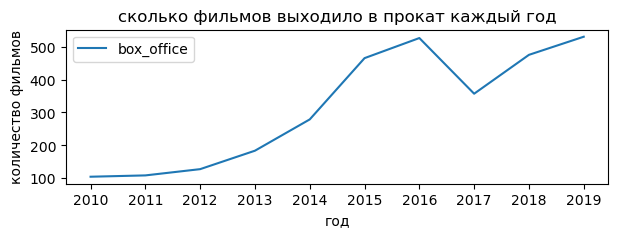

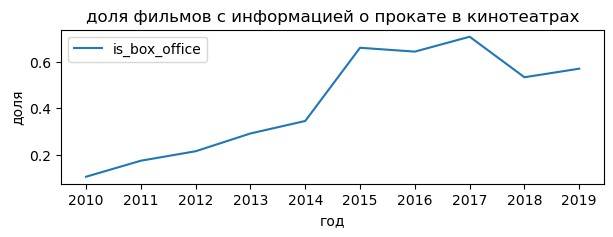

In [410]:
data['is_box_office'] = ~data['box_office'].isna()

a = pd.DataFrame(data.groupby('show_start_date_y')['box_office'].count())
b = pd.DataFrame(data.groupby('show_start_date_y')['is_box_office'].mean())
c = a.merge(b, on='show_start_date_y')
display (c)

a.plot(title='сколько фильмов выходило в прокат каждый год', ylabel="количество фильмов", xlabel="год", figsize=(7,2), xticks=a.index);

b.plot(title='доля фильмов с информацией о прокате в кинотеатрах', ylabel="доля", xlabel="год", figsize=(7,2), xticks=a.index);

# изначально пробовал такой вариант:
# display(data.pivot_table(index='show_start_date_y', values=['box_office', 'is_box_office'], aggfunc=['count', 'mean']))
# но он выдаёт лишнюю малозначимую информацию - если можно как-то элегантнее это сделать, буду рад узнать, как

display (f"Средняя доля фильмов, содержащая данные о прокате: {data['is_box_office'].mean()}")

In [411]:
b.sort_values(by="is_box_office", ascending=False)

,is_box_office
show_start_date_y,
2017,0.706931
2015,0.659574
2016,0.643032
2019,0.569892
2018,0.533109
2014,0.345725
2013,0.292063
2012,0.215852
2011,0.175241


- Доля фильмов с информацией о прокате в кинотеатрах по годам росла. В 2018 начался спад.
- В 2017 году наибольшая доля фильмов (71%) имеет информацию о прокате.

- С помощью сводной таблицы посчитем среднюю и медианную сумму сборов для каждого года.

,mean,median
,box_office,box_office
show_start_date_y,,
2010,2.313004e+04,1700.000
2011,1.293832e+05,3000.000
2012,5.433924e+04,5660.000
2013,1.619549e+05,3522.500
2014,2.668442e+07,18160.000
2015,8.494057e+07,4920933.000
2016,9.100057e+07,3846679.410
2017,1.360328e+08,9968340.000


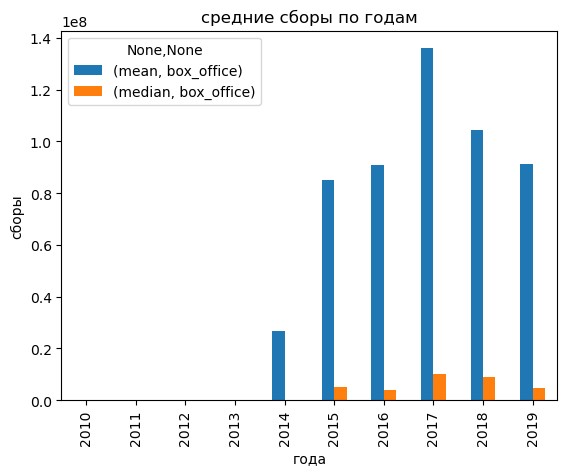

In [412]:
display(data.pivot_table(index='show_start_date_y', values='box_office', aggfunc=['mean', 'median']))

data.pivot_table(index='show_start_date_y', values='box_office', aggfunc=['mean', 'median']) \
    .plot(title='средние сборы по годам', y=['mean', 'median'], kind='bar', xlabel='года', ylabel='сборы');



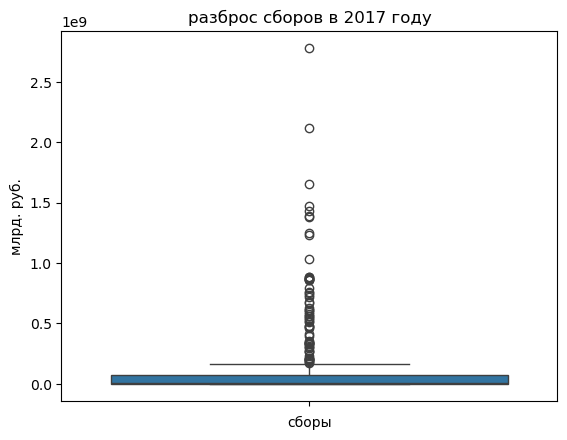

In [413]:
sns.boxplot(data.query('show_start_date_y == 2017')['box_office']) \
    .set(title='разброс сборов в 2017 году', xlabel='сборы', ylabel='млрд. руб.');

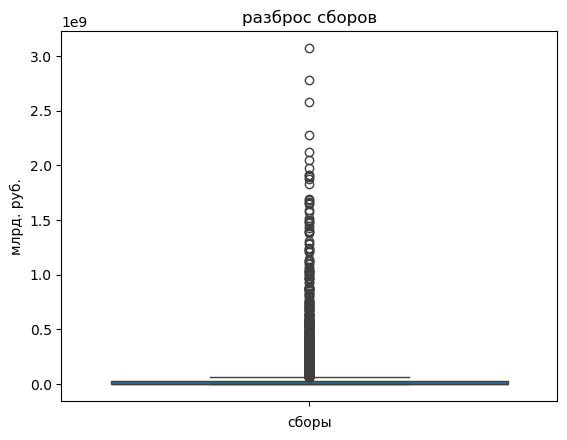

In [414]:
sns.boxplot(data['box_office']).set(title='разброс сборов', xlabel='сборы', ylabel='млрд. руб.');

Медианные значения сильно менше средних. Это вызвано наличием выбросов (фильмов с сильно выбивающимеся из общей статистики сборами) - это видно из диаграмм размаха.

- Посмотрим, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года?

,sum
,box_office
age_restriction,
«0+» - для любой зрительской аудитории,8.090774e+08
«12+» - для детей старше 12 лет,6.061945e+10
«16+» - для детей старше 16 лет,7.603473e+10
«18+» - запрещено для детей,4.075962e+10
«6+» - для детей старше 6 лет,5.579861e+10


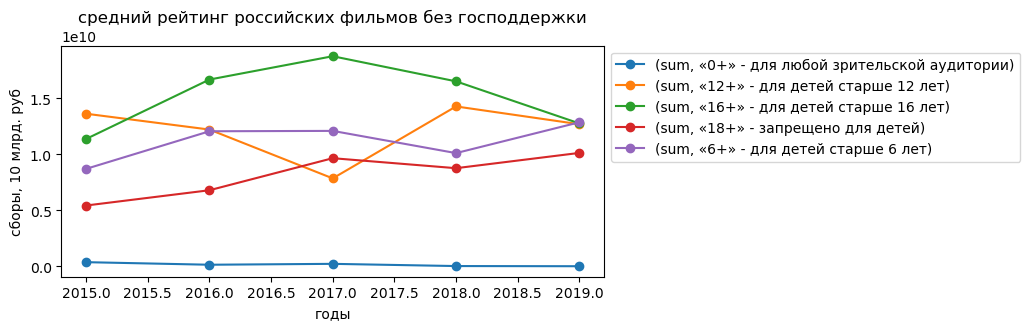

In [415]:
d_2015_2019 = data.query('show_start_date_y >= 2015 and show_start_date_y <= 2019')

display(d_2015_2019.pivot_table(index='age_restriction', values='box_office', aggfunc=['sum']))

a = d_2015_2019.pivot_table(index='show_start_date_y', values='box_office', columns='age_restriction', aggfunc=['sum'])

ax = a.plot(title='средний рейтинг российских фильмов без господдержки', kind='line', ylabel='сборы, 10 млрд. руб', xlabel = 'годы', figsize=(7,3), style='o-');
ax.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()


- Возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) влияет на сборы фильма в прокате в период с 2015 по 2019 год.
- Фильмы с возрастным ограничением «16+» собрали больше всего денег в прокате. Максимум был в 2017 году.
- Картина меняется в зависимости от года. Это может быть связано, что доля предоставленных непустых данных в поле box_office менялось примерно пропорционально сумме сборов. Нужно предоставлять эти данные по возможности, для всех фильмов, тогда и сравнение по годам станет более корректным, чем сейчас.

### Шаг 4. Исследуем фильмы, которые получили государственную поддержку

На этом этапе нет конкретных инструкций и заданий — поищем интересные закономерности в данных. Посмотрим, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

Поищем интересные закономерности в данных:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   pu_number              7486 non-null   string             
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7486 non-null   object             
 5   production_country     7486 non-null   object             
 6   director               7486 non-null   object             
 7   producer               7486 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64          

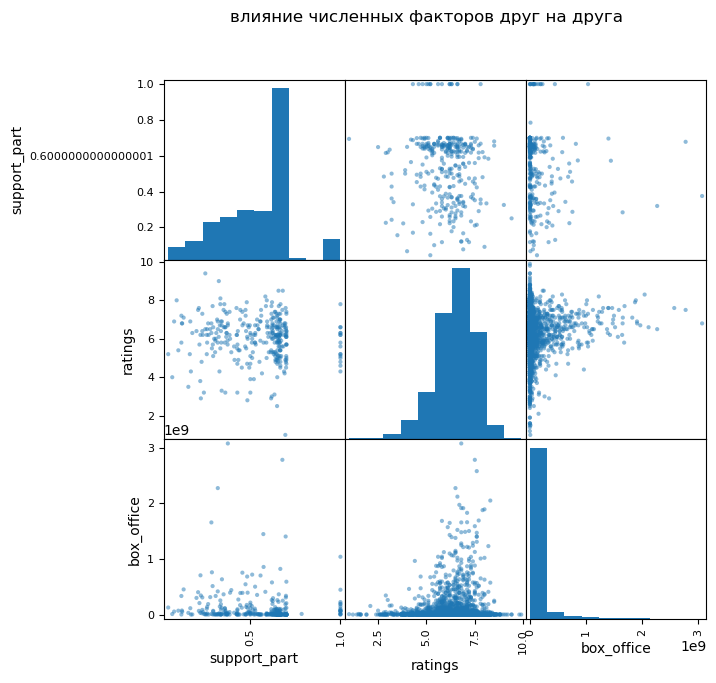

In [416]:
key_features = data [['support_part', 'ratings', 'box_office']]
data.info()
pd.plotting.scatter_matrix(key_features, figsize=(7,7))
plt.suptitle('влияние численных факторов друг на друга')
plt.show()

In [417]:
key_features.corr()

,support_part,ratings,box_office
support_part,1.000000,-0.070519,-0.084591
ratings,-0.070519,1.000000,0.087230
box_office,-0.084591,0.087230,1.000000


Выводы:
- Чем больше господдержка, тем активнее смотрят фильмы (однако среди них и те, которые нравятся большое, и те, которые нравятся меньше).
- прямой корреляции между долей господдержки и сборами нет.
- чем выше рейтинг, тем выше кассовые сборы - эта зависимость выражена ярче всего.

Проанализируем, как связаны размеры сборов с типом фильма:

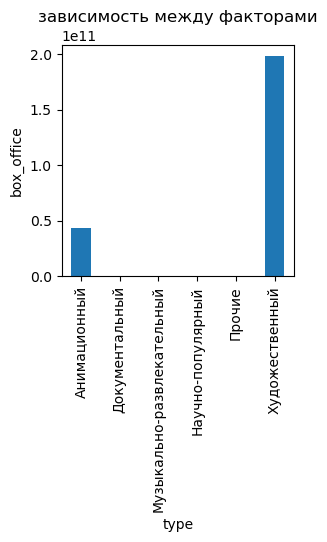

In [418]:
plot_two_factors(data, 'type', 'box_office')

<- больше сборов имеют художественные и анимационные фильмы

Проанализируем, как связаны размеры сборов со студией:

In [419]:
plot_two_factors(data, 'film_studio', 'box_office')

'слишком много значений для представлении на графике: 5491'

Проанализируем, как связаны размеры сборов со страной:

In [420]:
plot_two_factors(data, 'production_country', 'box_office')

'слишком много значений для представлении на графике: 950'

Проанализируем, как связаны размеры сборов с источником господдержки:

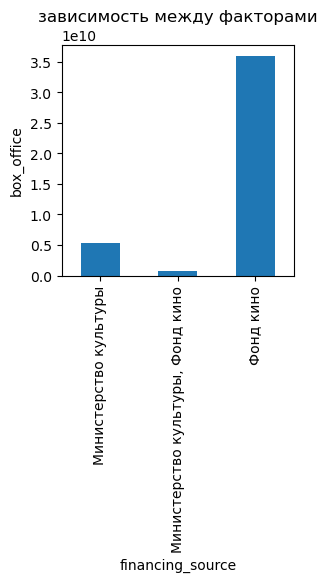

In [421]:
plot_two_factors(data, 'financing_source', 'box_office')

<- лидер по господдержке - "Фонд кино"

Проанализируем, как связаны размеры сборов с директором:

In [422]:
plot_two_factors(data, 'director_main', 'box_office')

'слишком много значений для представлении на графике: 4613'

Проанализируем, как связаны размеры сборов с жанром:

In [423]:
plot_two_factors(data, 'genres_main', 'box_office')

'слишком много значений для представлении на графике: 29'

Посмотрим, сколько выделяют средств на поддержку кино:

sum                                   \
financing_source  Министерство культуры Министерство культуры, Фонд кино   
show_start_date_y                                                          
2013                       2.650000e+07                              NaN   
2014                       2.115000e+08                      159502299.0   
2015                       1.100810e+09                      319382174.0   
2016                       7.498510e+08                      469200000.0   
2017                       3.510000e+08                       64346881.0   
2018                       9.260000e+08                       55000000.0   
2019                       1.471000e+09                      118000000.0   

                                 
financing_source      Фонд кино  
show_start_date_y                
2013               1.078479e+08  
2014               2.010000e+08  
2015               2.236049e+09  
2016               3.084104e+09  
2017               2.768625e+09  
2018               2.465969e+09  
2019               3.315000e+09

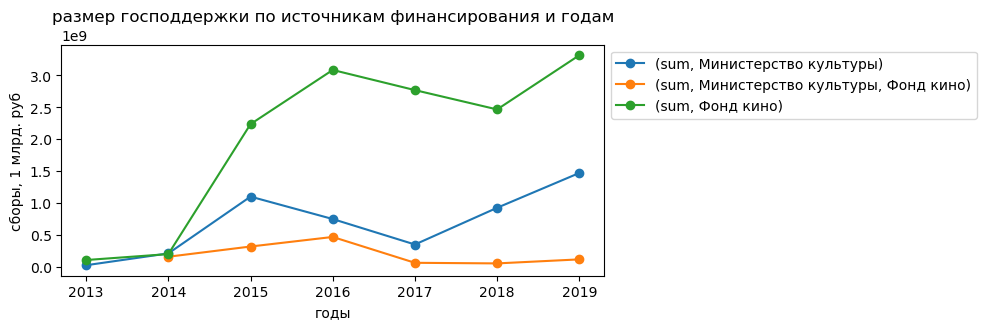

In [424]:
data ['support'] = data['refundable_support'] + data ['nonrefundable_support']
a = data.pivot_table(index='show_start_date_y', values='support', columns='financing_source', aggfunc=['sum'])
display (a)

ax = a.plot(title='размер господдержки по источникам финансирования и годам', kind='line', ylabel='сборы, 1 млрд. руб', xlabel = 'годы', figsize=(7,3), style='o-');
ax.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()


In [425]:
data.groupby(by='financing_source')['support'].sum()

financing_source
Министерство культуры               4.836661e+09
Министерство культуры, Фонд кино    1.185431e+09
Фонд кино                           1.417860e+10
Name: support, dtype: float64

Суммы, выделенные на господдержку - в таблице выше. Лидер - Фонд кино. Больше всего (согласно предоставленной информации) он выделил денег в 2019 году.

Проверим, хорошо ли окупаются такие фильмы, какой у них рейтинг:

'всего поддержанных фильмов: 332'

'общая выручка поддержанных фильмов: 15647540264'

show_start_date_y
2013   -1.007651e+08
2014    2.159397e+08
2015    1.082704e+09
2016    1.915607e+09
2017    6.343128e+09
2018    5.718374e+09
2019    4.725536e+08
Name: profit, dtype: float64

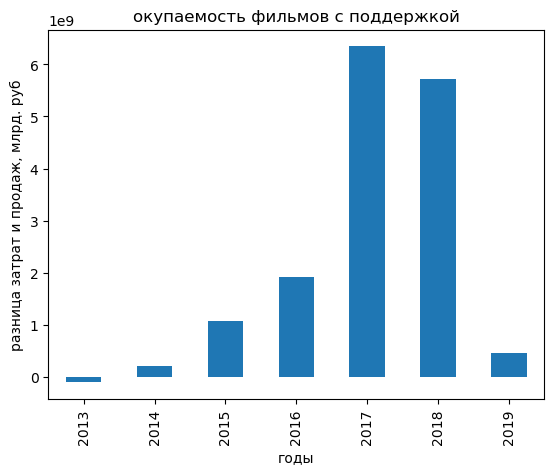

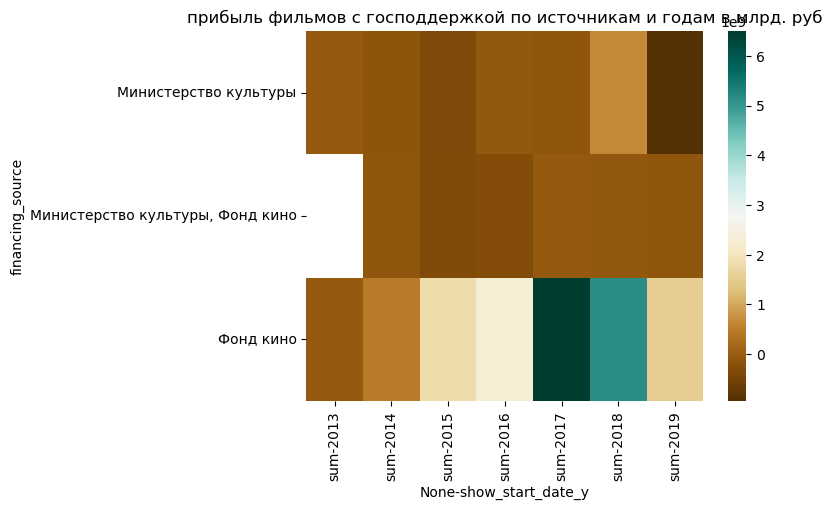

In [426]:
data['profit'] = data['box_office'] - ( data['budget'] - data['nonrefundable_support'] ) # nonrefundable_support не нужно возвращать, а значит вычтем его из расходов
supported_films = data.query('not (refundable_support.isna() and nonrefundable_support.isna())')
display(f"всего поддержанных фильмов: {len(supported_films)}")
display(f"общая выручка поддержанных фильмов: {supported_films['profit'].sum():.0f}")

a = supported_films.groupby('show_start_date_y')['profit'].sum()
display(a)
a.plot(y='profit', title='окупаемость фильмов с поддержкой', kind='bar',
       ylabel='разница затрат и продаж, млрд. руб', xlabel = 'годы');
plt.show()


a = supported_films.pivot_table(index='financing_source', values='profit', columns='show_start_date_y', aggfunc=['sum'])

ax = plt.axes()
ax.set_title('прибыль фильмов с господдержкой по источникам и годам в млрд. руб')
sns.heatmap(a, cmap='BrBG', ax = ax);

Cамая большая выгода была в год, когда поддержка была наибольшей

Построим на корреляцию поддержки и выручки для всех российских фильмов (нет смысла искать корреляцию господдержки с выручкой зарубежных фильмов):

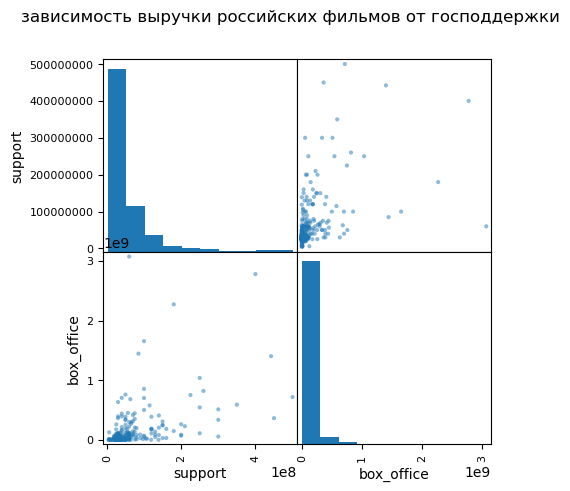

,support,box_office
support,1.000000,0.491826
box_office,0.491826,1.000000


In [427]:
ru_films = data.query('production_country == "Россия"')

pd.plotting.scatter_matrix(ru_films[['support', 'box_office']], figsize=(5,5))

plt.suptitle('зависимость выручки российских фильмов от господдержки')
plt.show()

ru_films[['support', 'box_office']].corr()

Имеется корреляция в 49%.

Кстати, а бы ли фильмы, которых господдержка спасла от убыточности?

In [428]:
films_failed_without_support = data.query ('(box_office < budget ) and (box_office > budget - nonrefundable_support)')
display(films_failed_without_support)

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,ratings,genres,box_office,show_start_date_y,director_main,genres_main,support_part,is_box_office,support,profit
2053,14+,111023614,2014-12-19 12:00:00+00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",«16+» - для детей старше 16 лет,0.0,...,6.6,мелодрама,1.023402e+07,2014,А.Зайцев,мелодрама,1.000000,True,23000000.0,1.023402e+07
2471,Pro любовь,111016615,2015-09-17 12:00:00+00:00,Художественный,"ООО ""Магнум-фильм""",Россия,А.Меликян,А.Меликян,«18+» - запрещено для детей,0.0,...,6.6,комедия,5.288230e+07,2015,А.Меликян,комедия,0.362352,True,20000000.0,1.768730e+07
2531,Черная вода,111018315,2015-10-09 12:00:00+00:00,Художественный,"ООО ""АРТЛАЙТ""",Россия,Р.Каримов,"А.Новиков, А.Котелевский",«16+» - для детей старше 16 лет,0.0,...,5.1,"ужасы,драма",1.607720e+07,2015,Р.Каримов,ужасы,0.662683,True,28000000.0,1.824695e+06
2684,Тряпичный союз,111010215,2015-06-08 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",«18+» - запрещено для детей,0.0,...,6.3,"комедия,драма",1.957739e+06,2015,М.Местецкий,комедия,1.000000,True,59000000.0,1.957739e+06
2699,Он - Дракон,111017915,2015-10-14 12:00:00+00:00,Художественный,"ООО ""ТаББаК""",Россия,И.Джендубаев,Т.Бекмамбетов,«6+» - для детей старше 6 лет,0.0,...,6.8,фэнтези,1.101714e+08,2015,И.Джендубаев,фэнтези,0.694444,True,250000000.0,1.714485e+05
3453,Ледокол,111016316,2016-10-11 12:00:00+00:00,Художественный,"ООО ""Продюсерская фирма Игоря Толстунова""",Россия,Н.Хомерики,"И.Толстунов, С.Козлов",«12+» - для детей старше 12 лет,100000000.0,...,6.5,драма,3.370697e+08,2016,Н.Хомерики,драма,0.697674,True,300000000.0,1.070697e+08
3462,Защитники,111000717,2017-01-24 12:00:00+00:00,Художественный,"ООО ""Энджой мувиз"", ООО ""РЕНОВАЦИО интертейнмент""",Россия,С.Андреасян,"С.Андреасян, Г.Андреасян, В.Поляков, А.Рязанцев",«12+» - для детей старше 12 лет,50000000.0,...,3.0,"фантастика,фэнтези,боевик",2.620403e+08,2017,С.Андреасян,фантастика,0.618750,True,200000000.0,8.880814e+07
3481,Землетрясение .,111016016,2016-09-23 12:00:00+00:00,Художественный,"ООО ""Кинокомпания МАРС-фильм"" по заказу ООО ""ММЕ""",Россия,С.Андреасян,"Р.Дишдишян, ООО ""ММЕ"", ООО ""КИНОКОМПАНИЯ БОЛЬШ...",«12+» - для детей старше 12 лет,15000000.0,...,6.8,драма,1.886056e+08,2016,С.Андреасян,драма,0.265724,True,55000000.0,2.162356e+07
3627,БОЛЬШОЙ,111017416,2016-11-22 12:00:00+00:00,Художественный,"ЗАО ""ПРОДЮСЕРСКАЯ КОМПАНИЯ ВАЛЕРИЯ ТОДОРОВСКОГО""",Россия,В.Тодоровский,"В.Тодоровский, А.Златопольский",«12+» - для детей старше 12 лет,10000000.0,...,8.5,"криминал,комедия,боевик",2.285782e+08,2016,В.Тодоровский,криминал,0.656250,True,210000000.0,1.085782e+08
3710,ДИГГЕРЫ,111012216,2016-07-29 12:00:00+00:00,Художественный,"ООО ""ВВП Альянс""",Россия,Т.Корнев,"А.Радько, Е.Гордецкая",«16+» - для детей старше 16 лет,10000000.0,...,3.1,ужасы,3.726671e+07,2016,Т.Корнев,ужасы,0.633874,True,30000000.0,9.938710e+06


<- да, вот эти 25 фильмов, они должны сказать "спасибо" господдержке.

Они хотя бы понравились они зрителям?

In [429]:
films_failed_without_support['ratings'].describe()

count    24.000000
mean      5.941667
std       1.491983
min       2.500000
25%       5.650000
50%       6.250000
75%       6.650000
max       8.500000
Name: ratings, dtype: float64

<- средняя оценка около 6

Повторим сравнения для рейтинга.

show_start_date_y
2013    6.700000
2014    6.006667
2015    6.139759
2016    5.677193
2017    6.000000
2018    6.001887
2019    6.176119
Name: ratings, dtype: float64

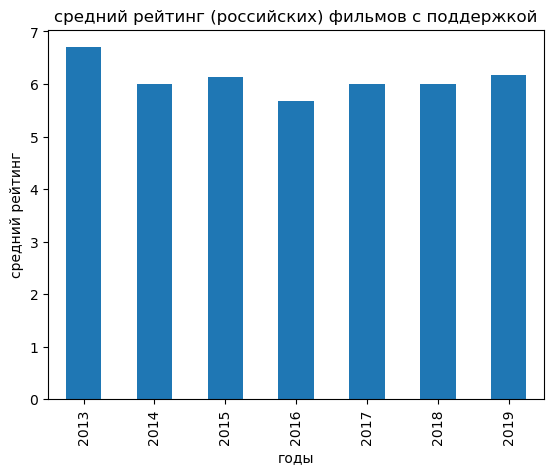

'средний рейтинг фильмов (российских) с господдержкой: 6.0'

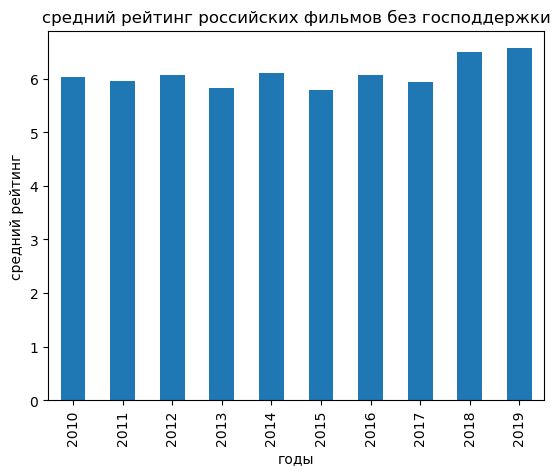

'средний рейтинг российских фильмов без господдержки: 6.2'

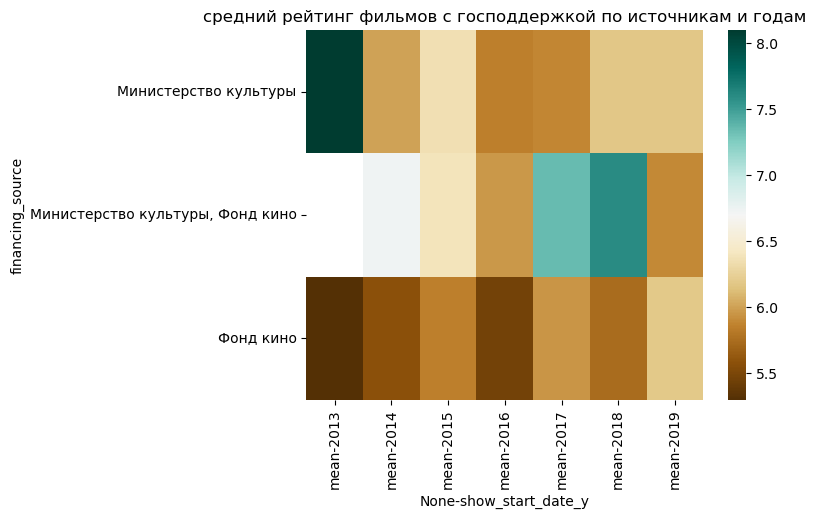

In [430]:
a = supported_films.groupby('show_start_date_y')['ratings'].mean()
display(a)
a.plot(y='ratings', title='средний рейтинг (российских) фильмов с поддержкой', kind='bar', ylabel='средний рейтинг', xlabel = 'годы');
plt.show()
display(f"средний рейтинг фильмов (российских) с господдержкой: {supported_films['ratings'].mean():.1f}")

ru_films_without_support = data.query('refundable_support.isna() and nonrefundable_support.isna() and production_country == "Россия"')
a = ru_films_without_support.groupby('show_start_date_y')['ratings'].mean()
a.plot(y='ratings', title='средний рейтинг российских фильмов без господдержки', kind='bar', ylabel='средний рейтинг', xlabel = 'годы');
plt.show()
display(f"средний рейтинг российских фильмов без господдержки: {ru_films_without_support['ratings'].mean():.1f}")

a = supported_films.pivot_table(index='financing_source', values='ratings', columns='show_start_date_y', aggfunc=['mean'])

ax = plt.axes()
ax.set_title('средний рейтинг фильмов с господдержкой по источникам и годам')
sns.heatmap(a, cmap='BrBG', ax = ax);

- По годам рейтинг меняется не сильно
- На рейтинг поддержка влияет в меньшей степени. Не видно всплеска хороших оценок в 2017 году у Фонда кино. А максимум - в той области, где было относительно немного  поддержки. Подтвердим также, посчитав корреляцию:

In [431]:
data[['support', 'ratings']].corr()

,support,ratings
support,1.000000,0.102222
ratings,0.102222,1.000000


### Шаг 5. Общий вывод

#### Главные выводы
Цель проекта: __"изучить рынок российского кинопроката и выявить текущие тренды, ответить на вопрос: насколько интересны зрителю фильмы, получившие государственную поддержку"__

Исследование основано на данных 2010-2019 годов

- В результате исследования выявлено наличичие определённого уровня зависимости между господдержкой и кассовыми сборами фильмов (корреляция 49%).
- Выявлено отсутствие зависимости между господдержкой и рейтингом фильмов (корреляция лишь 10%). Средний рейтинг российских фильмов без господдержки даже выше (6.2) фильмов с господдержкой (6.0).
- Чем больше господдержка, тем активнее смотрят фильмы (однако среди них и те, которые нравятся большое, и те, которые нравятся меньше).
- Есть фильмы, которые были бы убыточными без господдержки, но их не так много (25 из их 332), их список представлен выше, их средняя оценка 6.

#### Другие итоги проведённого исследования
- Проведена предобработка данных (см. отчёт в п. "Шаг 2 \ Итоги предобработки данных").
- По количеству выпущенных фильмов лидирует 2016 и 2019 годы (около 526 и 530 фильмов в год).
- Лишь 42% фильмов содержит информацию о прокате, 2017 год полнее всего представлен в данных (70% фильмов имеет информацию о прокате).
- Построена таблица по годам со средними и медианными сборами. Например, в 2017 году средний сбор составил 136 млн.
- Возрастное ограничение влияет на сборы, фильмы «16+» собрали больше всего денег в прокате. Максимум был в 2017 году.
- Чем выше рейтинг, тем выше кассовые сборы.
- Больше всего смотрят художественные фильмы, на втором мест анимационные.
- Всего 2 источника господдержки: Фонд кино (лидирует с 14 млрд. р.), Министерство культуры (500 млн), и их объединение (100 млн.). Больше всего Фонд кино выделил в 2019 году (118 млн.).
- Лишь в 2013 году были убыточные фильмы. Во все остальные года прибыть имеется, лидер - 2017 год (6 млрд. руб).

#### Рекомендации для сервиса
- В поле type есть лидирующие пробелы. Лучше убрать их из справочников/словарей при заполнении данных пользователем.
- Выявлена некорректность заполнения поля budget (см. отчёт в п. "Шаг 2 \ Итоги предобработки данных").
- Общая проблема для текстовых данных - несколько элементов (например, жанры) перечислены через запятую. Это может привести к проблемам парсинга. Лучше использовать для этого другие раздетели.